 Loading MNIST dataset...
Classifier initialized: CNN
 Training CNN model (demo mode: using 2000 samples for speed)...
Training CNN on cpu...
Epoch [1/10] - Loss: 1.6103, Accuracy: 46.85%
Epoch [2/10] - Loss: 0.7277, Accuracy: 77.20%
Epoch [3/10] - Loss: 0.5005, Accuracy: 84.50%
Epoch [4/10] - Loss: 0.3948, Accuracy: 87.30%
Epoch [5/10] - Loss: 0.2934, Accuracy: 91.30%
Epoch [6/10] - Loss: 0.2553, Accuracy: 92.05%
Epoch [7/10] - Loss: 0.2270, Accuracy: 93.50%
Epoch [8/10] - Loss: 0.1983, Accuracy: 94.10%
Epoch [9/10] - Loss: 0.1460, Accuracy: 95.40%
Epoch [10/10] - Loss: 0.1256, Accuracy: 95.50%
CNN Training Complete!


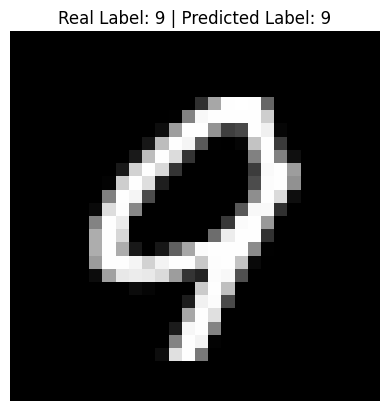

 Demo finished! Predicted digit: 9


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from mnist_classifier import MnistClassifier

# 1. Data Loading
print(" Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
x, y = mnist.data.reshape(-1, 28, 28), mnist.target.astype(int)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2. Model Training (CNN)
# We use the MnistClassifier wrapper, which internally calls the CNN class from models/cnn.py
clf = MnistClassifier(algorithm="cnn")
print(" Training CNN model (demo mode: using 2000 samples for speed)...")
clf.train(x_train[:2000], y_train[:2000])

# 3. Inference on a random test image
idx = np.random.randint(0, len(x_test))
prediction = clf.predict(x_test[idx:idx+1])[0]

# Visualization of the result
plt.imshow(x_test[idx], cmap='gray')
plt.title(f"Real Label: {y_test[idx]} | Predicted Label: {prediction}")
plt.axis('off')
plt.show()

print(f" Demo finished! Predicted digit: {prediction}")